##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader

from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode

c:\Users\Roros\.conda\envs\cv_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [8]:
MODEL_ID = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID)


model.eval()
print(f"Model {MODEL_ID} loaded on {device}")

Model facebook/dinov2-small loaded on cpu


In [9]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [11]:
dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

100.0%
100.0%


In [12]:
# Select 20 images
#    10 Cats + 10 Dogs

selected_indices = []

cat_count = 0
dog_count = 0

for i in range(len(dataset)):

    _, label = dataset[i]

    # Cats labels: 0-11
    if label < 12 and cat_count < 10:
        selected_indices.append(i)
        cat_count += 1

    # Dogs labels: 12-36
    elif label >= 12 and dog_count < 10:
        selected_indices.append(i)
        dog_count += 1

    if len(selected_indices) == 20:
        break

subset = Subset(dataset, selected_indices)

loader = DataLoader(
    subset,
    batch_size=1,
    shuffle=False
)

In [13]:
# Extract CLS Tokens

features = []
true_labels = []

with torch.no_grad():

    for image, label in loader:

        inputs = {
            "pixel_values": image.to(device)
        }

        outputs = model(**inputs)

        # CLS token
        cls_token = outputs.last_hidden_state[:, 0, :]

        # Convert to numpy
        cls_vector = cls_token.cpu().numpy().flatten()

        features.append(cls_vector)

        # Binary labels
        # 0 = Cat
        # 1 = Dog
        binary_label = 0 if label.item() < 12 else 1

        true_labels.append(binary_label)

# Convert to arrays
features = np.array(features)
true_labels = np.array(true_labels)

print("Feature shape:", features.shape)


Feature shape: (20, 384)


In [14]:
# Apply K-Means Clustering

kmeans = KMeans( n_clusters=2, random_state=42, n_init=10)

clusters = kmeans.fit_predict(features)

print("\nCluster IDs:")
print(clusters)


Cluster IDs:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [15]:
#  Map Clusters to True Labels

mapped_clusters = np.zeros_like(clusters)

for cluster_id in range(2):

    mask = (clusters == cluster_id)

    majority_label = mode( true_labels[mask], keepdims=True)[0]

    mapped_clusters[mask] = majority_label

In [16]:
# Evaluation

accuracy = accuracy_score(true_labels, mapped_clusters)

print("\nClustering Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, mapped_clusters
))



Clustering Accuracy:
100.00%

Confusion Matrix:
[[10  0]
 [ 0 10]]


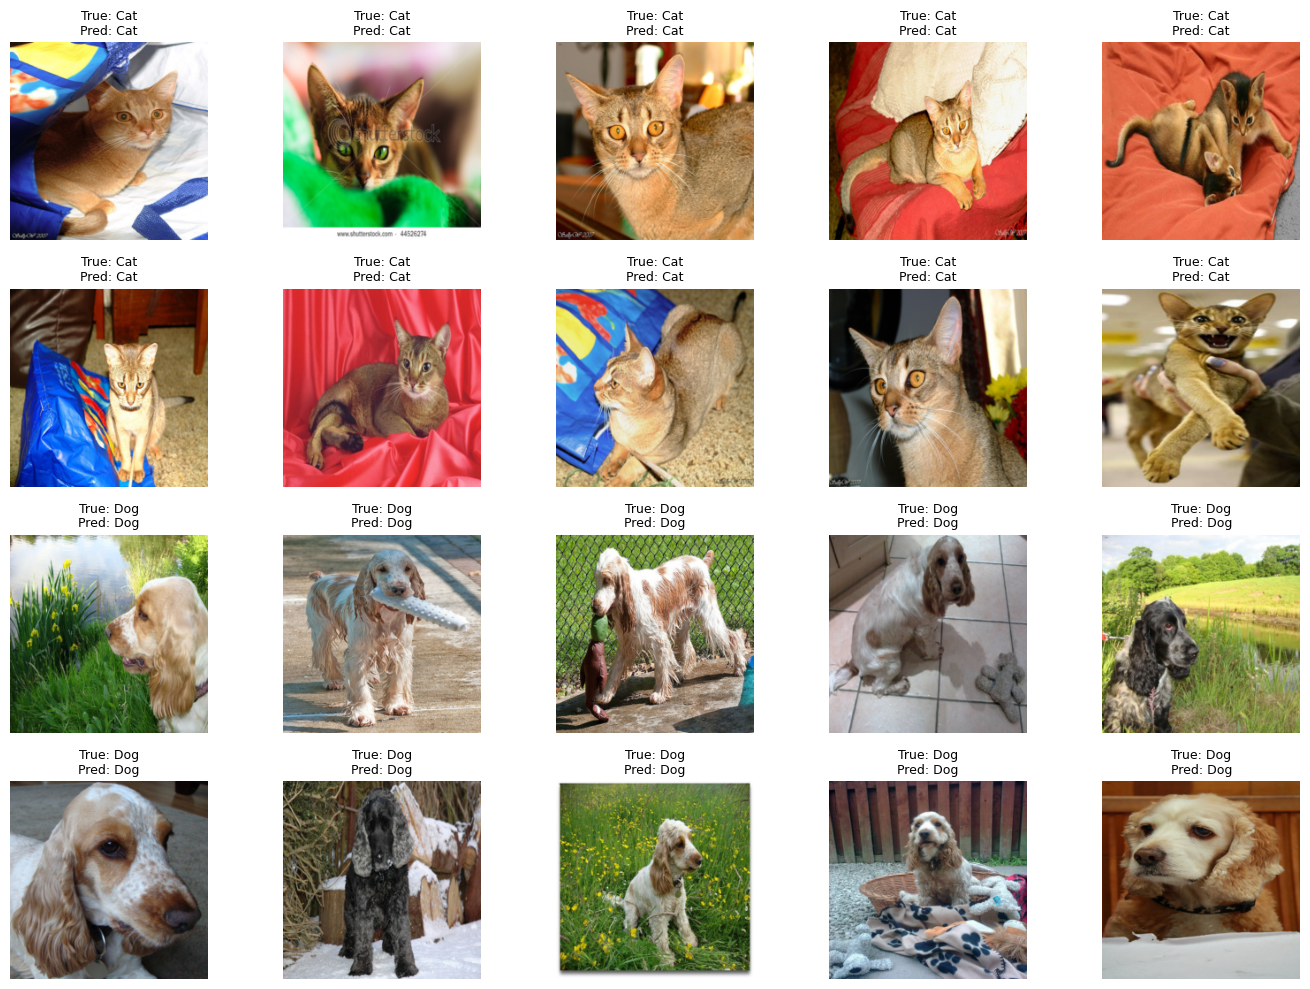

In [17]:
# Visualization

fig, axes = plt.subplots(4, 5, figsize=(14, 10))

for idx, ax in enumerate(axes.flat):

    image, label = subset[idx]

    image_np = image.permute(1, 2, 0).numpy()

    true_name = "Cat" if label < 12 else "Dog"

    pred_name = (
        "Cat"
        if mapped_clusters[idx] == 0
        else "Dog"
    )

    ax.imshow(image_np)

    ax.set_title(
        f"True: {true_name}\nPred: {pred_name}",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Print Final Results

print("\nTrue Labels:")
print(true_labels)

print("\nPredicted Labels:")
print(mapped_clusters)


True Labels:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

Predicted Labels:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [22]:
from transformers import AutoModelForImageClassification

In [20]:
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageClassification.from_pretrained(MODEL_ID)

model.eval()
print(f"Model {MODEL_ID} loaded on {device}")

C:\Users\Roros\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Roros\.cache\huggingface\hub\models--facebook--dinov2-small-imagenet1k-1-layer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fal

Model facebook/dinov2-small-imagenet1k-1-layer loaded on cpu


In [25]:
image = Image.open(r'C:\Users\Roros\Documents\GitHub\arti560-computer-vision-labs\lab10-visual-representations\Golden Retriever.jpg').convert("RGB")

In [26]:
inputs = processor(
    images=image,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

In [27]:
#  Run Inference
with torch.no_grad():

    outputs = model(**inputs)


In [28]:
# 6. Predicted Class

logits = outputs.logits

predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

confidence = torch.softmax(logits, dim=-1)[0][predicted_class_idx].item()

In [29]:
# Results

print("\nPredicted Class:")
print(predicted_label)

print("\nConfidence:")
print(f"{confidence * 100:.2f}%")


Predicted Class:
golden retriever

Confidence:
88.79%


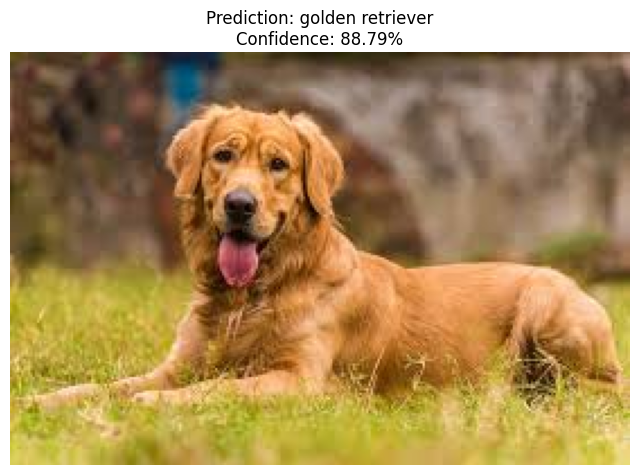

In [30]:
#  Show Image

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.title(
    f"Prediction: {predicted_label}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()